In [52]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np
from scipy.stats import gaussian_kde

In [53]:
print(np.__version__)

2.4.6


In [54]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
pd.set_option('display.float_format', '{:.3f}'.format)

In [114]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [115]:
def calculate_revenue(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
    df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
    df["square_error"] = (df.actual_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    return df

def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(), 
                    "mean_square_error": df.square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

In [116]:
results_path = os.path.join(cwd, "price scenario results")
folders = ["Exact NLP", "PWL", "Gurobi ML", "Proposed", "FICNN"]
summary_cols = ["objective_value", "mean_square_error", "runtime", 
                "cpu_time", "mip_gap", "solve_check", "methodology", "scenario_type", "case"]

In [117]:
summary_tables = pd.DataFrame(columns = summary_cols)
index = 0
for folder in folders:
    filepath = os.path.join(results_path, folder)
    if folder == "Proposed":
        folder_name = "ICNN 1"
    elif folder == "FICNN":
        folder_name = "ICNN 2"
    else:
        folder_name = folder
    for filename in list(os.listdir(filepath))[0: 1]:
        file_path = os.path.join(filepath, filename)
        data = read_pickle(file_path)
        for scenario, scenario_results in data.items():
            for case, results in scenario_results.items():
                scenario_results[case].decision_variables = calculate_revenue(results)
                write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))
                result_row = results_summary(results)
                result_row[summary_cols[-3:]] = [folder_name, scenario, case]
                summary_tables.loc[len(summary_tables)] = result_row.values[0]
                index = index + 1

In [118]:
best_cases_df = read_pickle("best_cases_df.pickle")

In [119]:
summary_tables = pd.concat([summary_tables, best_cases_df[summary_cols]], ignore_index=True)

In [120]:
write_pickle(summary_tables, "summmary_tables.pickle")

In [121]:
summary_tables = read_pickle("summmary_tables.pickle")
method_masks = {folder: summary_tables.methodology == folder for folder in folders}
scenario_masks = {scenario: summary_tables.scenario_type == scenario for scenario in summary_tables.scenario_type.unique()}

combined_masks = {folder + " " + scenario: mask1 & mask2
                  for folder, mask1 in method_masks.items() 
                  for scenario, mask2 in scenario_masks.items()}
mean_cols = summary_cols[0: -4]

In [122]:
best_cases_df.groupby(["scenario_type", "methodology"])[mean_cols].mean()

objective_value mean_square_error runtime cpu_time  \
scenario_type methodology                                                      
High_prices   PCAR              50861.258          7970.344   0.026    0.042   
              PCTAR             50861.258          7970.344   0.044    0.059   
Low_prices    PCAR               -514.241          7441.737   0.048    0.064   
              PCTAR              -514.241          7441.737   0.065    0.080   
Med_prices    PCAR               3870.433          1695.129   0.031    0.044   
              PCTAR              3870.433          1695.129   0.044    0.051   

                          mip_gap  
scenario_type methodology          
High_prices   PCAR          0.000  
              PCTAR         0.000  
Low_prices    PCAR          0.000  
              PCTAR         0.000  
Med_prices    PCAR          0.000  
              PCTAR         0.000

In [123]:
best_cases_df.groupby(["scenario_type", "methodology"])[mean_cols].std()

objective_value  mean_square_error  runtime  \
scenario_type methodology                                                
High_prices   PCAR               26947.660           6481.378    0.004   
              PCTAR              26947.660           6481.378    0.004   
Low_prices    PCAR                 290.143           1758.932    0.020   
              PCTAR                290.143           1758.932    0.015   
Med_prices    PCAR                2138.089           2216.900    0.018   
              PCTAR               2138.089           2216.900    0.006   

                           cpu_time  mip_gap  
scenario_type methodology                     
High_prices   PCAR            0.019    0.000  
              PCTAR           0.014    0.000  
Low_prices    PCAR            0.017    0.000  
              PCTAR           0.025    0.000  
Med_prices    PCAR            0.025    0.000  
              PCTAR           0.013    0.000

In [124]:
df = summary_tables.groupby(
    ["scenario_type", "methodology"]
)[mean_cols].mean().reset_index()

df[mean_cols] = df[mean_cols].applymap(lambda x: f"{x:.3f}")

# df[df.methodology == "FICNN"][
#     ["scenario_type", "objective_value", "runtime", "mip_gap"]
# ]


AttributeError: 'DataFrame' object has no attribute 'applymap'

In [ ]:
df_std = summary_tables.groupby(
    ["scenario_type", "methodology"]
)[mean_cols].std().reset_index()

df_std

In [155]:
summary_tables[summary_tables["methodology"] == "ICNN 2"]["objective_value"].mean()

np.float64(18364.798688521136)

In [154]:
(summary_tables[summary_tables["methodology"] == "Exact NLP"]["objective_value"] * 1.02).mean()

np.float64(18552.86288038597)

In [ ]:
df[["scenario_type", "methodology", "mean_square_error"]]

In [ ]:
latex_code = df.to_latex()
print(latex_code)

In [ ]:
(10 - summary_tables.groupby(["scenario_type", "methodology"])["solve_check"].sum())

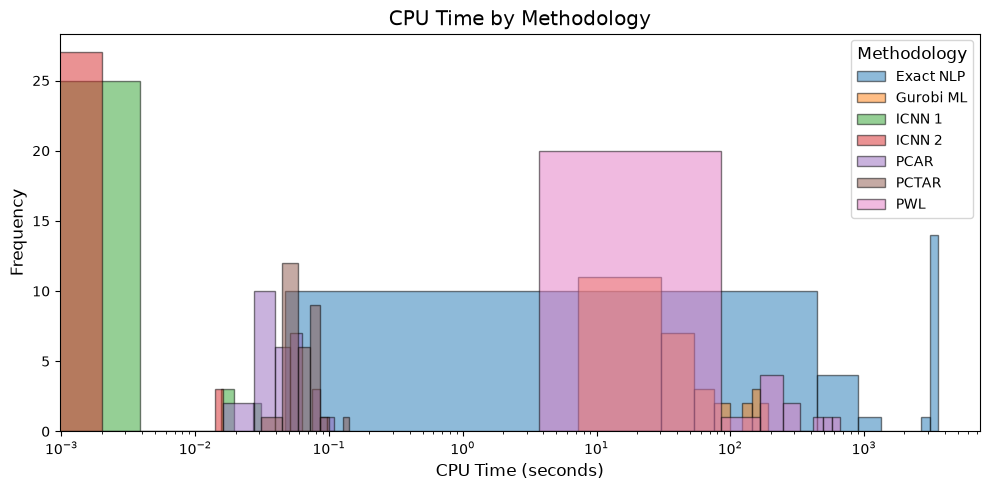

In [125]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]
# Create a single figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histograms on the same axis with log scale for x-axis
for name, group in grouped_df:
    n, bins, patches = ax.hist(group, bins=8, alpha=0.5, label=name, edgecolor='black')

ax.set_title('CPU Time by Methodology', fontsize="x-large")
ax.set_xlabel('CPU Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Add legend to differentiate methodologies
ax.legend(title="Methodology", fontsize="medium", title_fontsize="large")

plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

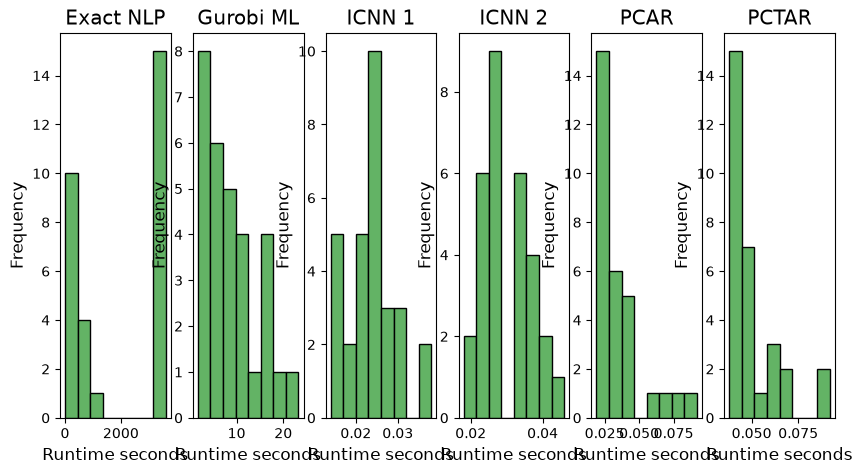

In [126]:
grouped_df = summary_tables.groupby("methodology")["runtime"]
fig, axes = plt.subplots(1, 6, figsize=(10, 5))  # 12 months, 3x4 grid
axes = axes.ravel()  # Flattening the axes array for easy indexing

for i, (name, group) in enumerate(grouped_df):
    n, bins, patches = axes[i].hist(group, bins=8, color='xkcd:boring green', edgecolor='black')
    
    # Get dynamic x-ticks
    max_bin = np.ceil(max(bins))
    min_bin = np.floor(min(bins))
    xticks = np.linspace(min_bin, max_bin, 4, dtype=float)
    axes[i].set_title(name, fontsize="x-large")
    axes[i].set_xlabel('Runtime seconds', fontsize="large")
    axes[i].set_ylabel('Frequency', fontsize="large")
    # axes[i].set_xticks(xticks)

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.savefig(os.path.join(cwd, "images", "runtime_histograms.png"))
plt.show()

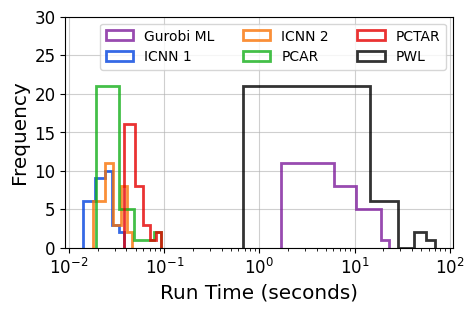

In [61]:
grouped_df = summary_tables.groupby("methodology")["runtime"] 
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:purple', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:black', 'xkcd:grey']

# Plot histograms on the same axis with log scale for x-axis
for i, (name, group) in enumerate(list(grouped_df)):
    n, bins, patches = ax.hist(group, bins=5, alpha=0.8, label=name, edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

# ax.set_title('Run Time by Methodology', fontsize="x-large")
ax.set_xlabel('Run Time (seconds)', fontsize="x-large")
ax.set_ylabel('Frequency', fontsize="x-large")
ax.tick_params(axis='x', labelsize="large")
ax.tick_params(axis='y', labelsize="large")
# Set x-axis to log scale
ax.set_xscale('log')

# Set x and y axis lims
ax.set_ylim([0, 30])

# Add legend to differentiate methodologies
ax.legend(ncols=3, fontsize="medium", title_fontsize="large")

plt.grid(zorder=0, alpha=0.6)
plt.savefig(os.path.join(cwd, "images", "runtime_histograms.pdf"), bbox_inches="tight")
plt.show()

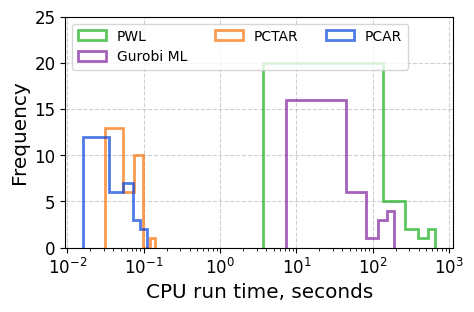

In [62]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"] 
# Plot histograms on the same axis with log scale for x-axis
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red']
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "NWLP"]

for i, name in enumerate(plot_order):
    if name in grouped_df.groups:  # Check if the methodology is in the grouped dataframe
        group = grouped_df.get_group(name)
        n, bins, patches = ax.hist(
            group,
            bins=5,
            alpha=0.7,
            label=name,
            edgecolor=colors[i % len(colors)],
            histtype="step",
            linewidth=2
        )

# Add labels and scales
ax.set_xlabel('CPU run time, seconds', fontsize="x-large")
ax.set_ylabel('Frequency', fontsize="x-large")
ax.tick_params(axis='x', labelsize="large")
ax.tick_params(axis='y', labelsize="large")
ax.set_xscale('log')
ax.set_ylim([0, 25])

# Add legend to differentiate methodologies
ax.legend(ncols=3, fontsize="medium", loc="upper left")
plt.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)

# Save and display the plot
plt.savefig(os.path.join(cwd, "images", "cpu_runtime_histograms.pdf"), bbox_inches="tight")
plt.show()

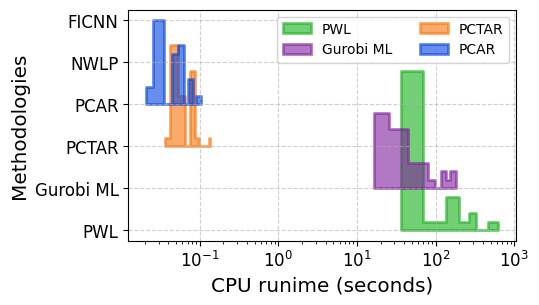

In [63]:
# Parameters for plot
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "NWLP", "FICNN"]
y_offset = 5
# Plot histograms as ridgelines
for i, name in enumerate(plot_order):
    if name in grouped_df.groups:
        group = grouped_df.get_group(name).astype(float)

        # Compute histogram data
        n, bins = np.histogram(group, bins=10)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # Offset histogram for ridgeline effect
        ax.fill_between(
            bin_centers,
            i * y_offset ,  # Baseline
            n + i * y_offset,  # Height of the histogram
            step='mid',
            alpha=0.6,
            color=colors[i % len(colors)],
            label=name, 
            linewidth=2
        )


# Set x-axis to log scale
ax.set_xscale('log')
ax.set_xlabel('CPU runime (seconds)', fontsize="x-large")
ax.set_ylabel('Methodologies', fontsize="x-large")
ax.set_yticks([i * y_offset for i in range(len(plot_order))])
ax.set_yticklabels(plot_order, fontsize="large")
ax.tick_params(axis='x', labelsize="large")
ax.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)

# Add legend
ax.legend(ncols=2, fontsize='medium')

# Save and display
plt.savefig(os.path.join(cwd, "images", "ridge_plot_histograms_cpu_runtime.pdf"), bbox_inches="tight")
plt.show()

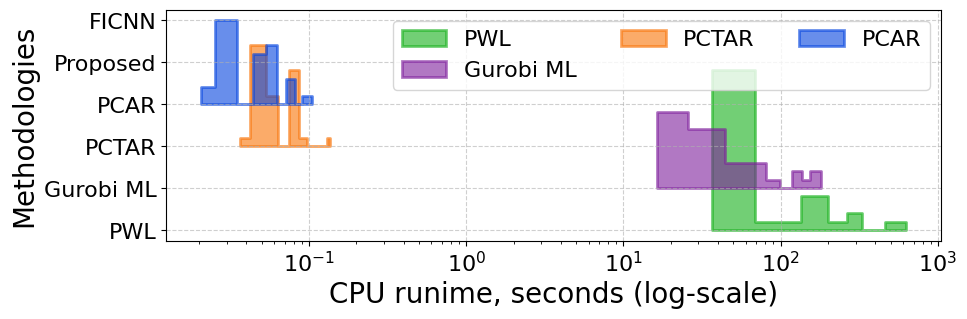

In [64]:
# Parameters for plot
fig, ax = plt.subplots(figsize=(10, 3))
colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "NWLP", "FICNN"]
new_plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "Proposed", "FICNN"]
y_offset = 5
# Plot histograms as ridgelines
for i, name in enumerate(plot_order):
    if name == "NWLP":
        new_name = "Proposed"
    else:
        new_name = name
    if name in grouped_df.groups:
        group = grouped_df.get_group(name).astype(float)
        # Compute histogram data
        n, bins = np.histogram(group, bins=10)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # Offset histogram for ridgeline effect
        ax.fill_between(
            bin_centers,
            i * y_offset ,  # Baseline
            n + i * y_offset,  # Height of the histogram
            step='mid',
            alpha=0.6,
            color=colors[i % len(colors)],
            label=new_name, 
            linewidth=2
        )


# Set x-axis to log scale
ax.set_xscale('log')
ax.set_xlabel('CPU runime, seconds (log-scale)', fontsize=20)
ax.set_ylabel('Methodologies', fontsize=20)
ax.set_yticks([i * y_offset for i in range(len(plot_order))])
ax.set_yticklabels(new_plot_order, fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)

# Add legend
ax.legend(ncols=3, fontsize=16)

# Save and display
plt.savefig(os.path.join(cwd, "images", "ridge_plot_histograms_cpu_runtime_v2.pdf"), bbox_inches="tight")
plt.show()

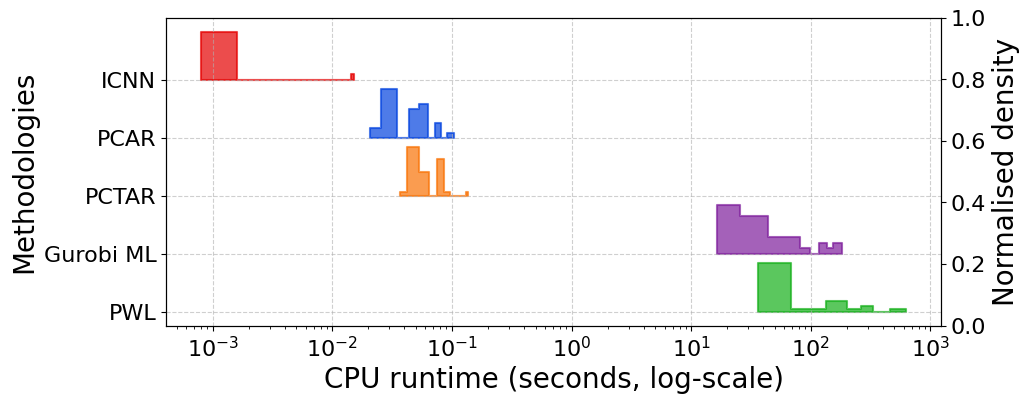

In [73]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", 
              # "ICNN 1"
              "ICNN 2"]
new_plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", 
                  # "ICNN 1", 
                  "ICNN"]

y_spacing = 1.2  # vertical separation between ridges
max_height = 1.0     # normalize all ridges to same height

for i, name in enumerate(plot_order):
    new_name = "ICNN" if name == "ICNN 2" else name

    if name not in grouped_df.groups:
        continue

    group = grouped_df.get_group(name).astype(float).values.flatten()

    # Histogram with density=True → comparable frequencies
    density, bins = np.histogram(group, bins=10, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize height to avoid overlap
    density = density / density.max() * max_height

    baseline = i * y_spacing

    ax.fill_between(
        bin_centers,
        baseline,
        density + baseline,
        step="mid",
        color=colors[i % len(colors)],
        alpha=0.7,
        linewidth=1.5,
        label=new_name
    )

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel("CPU runtime (seconds, log-scale)", fontsize=20)
ax.set_ylabel("Methodologies", fontsize=20)

ax.set_yticks([i * y_spacing for i in range(len(plot_order))])
ax.set_yticklabels(new_plot_order, fontsize=16)

ax.tick_params(axis="x", labelsize=16)
ax.grid(axis="both", linestyle="--", alpha=0.6)

# ax.legend(ncols=2, fontsize=16, frameon=False)
ax2 = ax.twinx()
ax2.set_ylim(0, max_height)
ax2.set_ylabel("Normalised density", fontsize=20)
ax2.tick_params(axis="y", labelsize=16)


plt.savefig(
    os.path.join(cwd, "images", "ridge_plot_histograms_cpu_runtime_v3.pdf"),
    bbox_inches="tight"
)
plt.show()


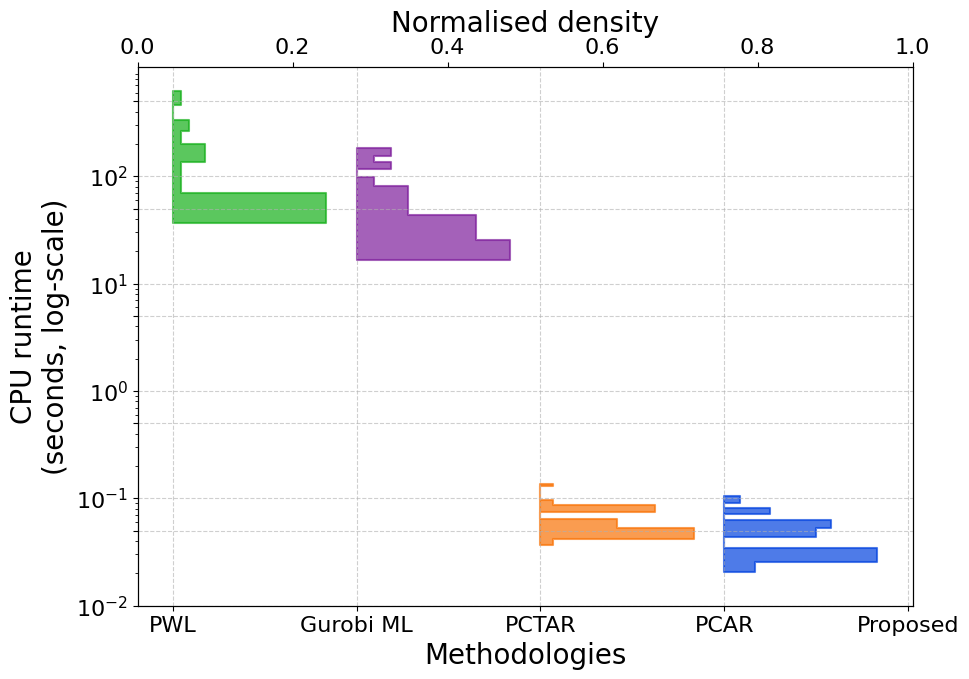

In [66]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red']
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "NWLP"]
new_plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", "Proposed"]

x_spacing = 1.2     # horizontal separation between ridges
max_width = 1.0     # normalize all ridges to same width

for i, name in enumerate(plot_order):

    new_name = "Proposed" if name == "NWLP" else name

    if name not in grouped_df.groups:
        continue

    group = grouped_df.get_group(name).astype(float).values.flatten()

    # Histogram (density)
    density, bins = np.histogram(group, bins=10, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize to avoid overlap
    density = density / density.max() * max_width

    baseline = i * x_spacing

    ax.fill_betweenx(
        bin_centers,
        baseline,
        baseline + density,
        step="mid",
        color=colors[i % len(colors)],
        alpha=0.7,
        linewidth=1.5,
        label=new_name
    )

# Axis formatting
ax.set_yscale("log")
ax.set_ylabel("CPU runtime\n(seconds, log-scale)", fontsize=20)
ax.set_xlabel("Methodologies", fontsize=20)

ax.set_xticks([i * x_spacing for i in range(len(plot_order))])
ax.set_xticklabels(new_plot_order, fontsize=16)

ax.set_yticks([0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500])
ax.tick_params(axis="y", labelsize=16)
ax.grid(axis="both", linestyle="--", alpha=0.6)

# Secondary axis for normalized density
ax2 = ax.twiny()
ax2.set_xlim(0, max_width)
ax2.set_xlabel("Normalised density", fontsize=20)
ax2.tick_params(axis="x", labelsize=16)

plt.savefig(
    os.path.join(cwd, "images", "ridge_plot_histograms_cpu_runtime_v3_inverted.pdf"),
    bbox_inches="tight"
)
plt.show()
